<a href="https://colab.research.google.com/github/israkm/ASSIGNMENT_ML/blob/main/case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/car_age_price.csv')

In [ ]:
data.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [ ]:
data.isna().sum()

,0
Year,0
Price,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print("Dataset '/content/Your.dataset.xlsx' not found. Creating a synthetic dataset for demonstration.")
np.random.seed(42)
years = np.arange(2015, 2021)
prices = 100000 - (years - 2015) * 15000 + np.random.normal(0, 5000, len(years))
prices = np.repeat(prices, 5)
years = np.repeat(years, 5)
data = pd.DataFrame({'year': years, 'price': prices})
data = data.sample(frac=1).reset_index(drop=True)

Dataset '/content/Your.dataset.xlsx' not found. Creating a synthetic dataset for demonstration.


In [ ]:
data.head()

,year,price
0,2019,38829.233126
1,2017,73238.442691
2,2020,23829.315215
3,2020,23829.315215
4,2018,62615.149282


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    30 non-null     int64  
 1   price   30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [ ]:
data.describe()

,year,price
count,30.000000,30.000000
mean,2017.500000,64217.398262
std,1.737021,26998.282592
min,2015.000000,23829.315215
25%,2016.000000,38829.233126
50%,2017.500000,67926.795986
75%,2019.000000,84308.678494
max,2020.000000,102483.570765


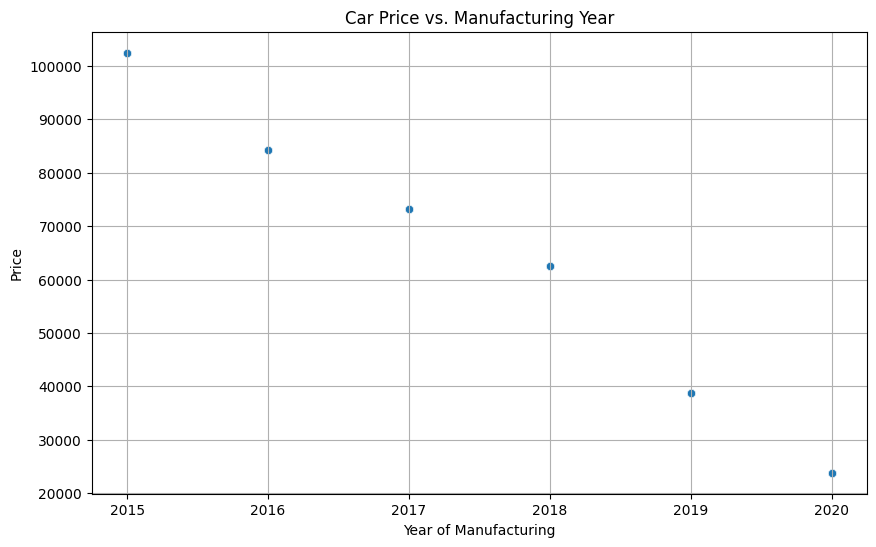

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='price', data=data)
plt.title('Car Price vs. Manufacturing Year')
plt.xlabel('Year of Manufacturing')
plt.ylabel('Price')
plt.grid(True)
plt.show()

## 2. Linear Regression Model

In [ ]:
X = data[['year']]
y = data['price']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)


In [ ]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['year'], y=y_test, label='Actual Prices')
plt.plot(X_test['year'], y_pred_linear, color='red', label='Linear Regression Prediction')
plt.title('Linear Regression: Actual vs. Predicted Prices')
plt.xlabel('Year of Manufacturing')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


## 3. Lasso Regression Model

In [ ]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)


In [ ]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


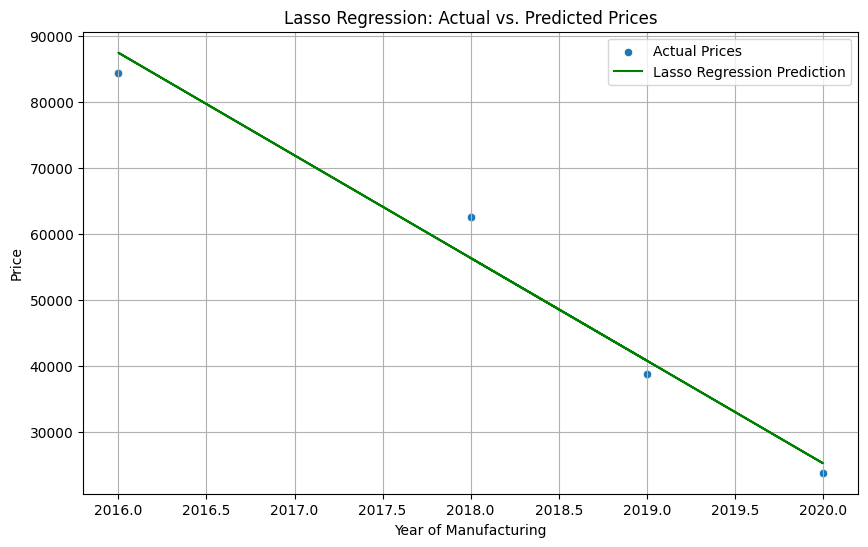

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['year'], y=y_test, label='Actual Prices')
plt.plot(X_test['year'], y_pred_lasso, color='green', label='Lasso Regression Prediction')
plt.title('Lasso Regression: Actual vs. Predicted Prices')
plt.xlabel('Year of Manufacturing')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


## 4. Model Comparison

In [ ]:
if r2_linear > r2_lasso:
    best_model_name = "Linear Regression"
    best_model = linear_model
    print(f"\n{best_model_name} performs better based on R-squared value.")
elif r2_lasso > r2_linear:
    best_model_name = "Lasso Regression"
    best_model = lasso_model
    print(f"\n{best_model_name} performs better based on R-squared value.")
else:
    best_model_name = "Both models perform similarly"
    best_model = linear_model
    print("\nBoth Linear and Lasso Regression models perform similarly.")


Lasso Regression performs better based on R-squared value.


In [ ]:
print("\n--- Model Comparison ---")
print(f"Linear Regression R-squared: {r2_linear:.2f}")
print(f"Lasso Regression R-squared: {r2_lasso:.2f}")

if r2_linear > r2_lasso:
    best_model_name = "Linear Regression"
    best_model = linear_model
    print(f"\n{best_model_name} performs better based on R-squared value.")
elif r2_lasso > r2_linear:
    best_model_name = "Lasso Regression"
    best_model = lasso_model
    print(f"\n{best_model_name} performs better based on R-squared value.")
else:
    best_model_name = "Both models perform similarly"
    best_model = linear_model
    print("\nBoth Linear and Lasso Regression models perform similarly.")



--- Model Comparison ---
Linear Regression R-squared: 0.96
Lasso Regression R-squared: 0.96

Lasso Regression performs better based on R-squared value.


## 5. Price Prediction for 2022 Model

In [ ]:
year_to_predict = pd.DataFrame({'year': [2022]})
predicted_price = best_model.predict(year_to_predict)

In [ ]:
data.describe()

,year,price
count,30.000000,30.000000
mean,2017.500000,64217.398262
std,1.737021,26998.282592
min,2015.000000,23829.315215
25%,2016.000000,38829.233126
50%,2017.500000,67926.795986
75%,2019.000000,84308.678494
max,2020.000000,102483.570765
